#  Customer Churn Prediction using Machine Learning

##  Business Problem
Customer churn is one of the biggest challenges faced by subscription-based businesses.
The objective of this project is to predict whether a customer is likely to leave the company based on customer demographics, services subscribed, billing information, and account characteristics.

---

##  Models Used
- Random Forest
- XGBoost
- Gradient Boosting
- HistGradientBoosting

---

##  Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- Cross Validation Accuracy

#  Loading Dataset

The IBM Telco Customer Churn dataset contains customer demographics, subscription information, account details, and churn labels.

Our goal is to predict whether a customer will churn (`Yes`) or remain with the company (`No`).

In [1]:
import platform
print(platform.python_version())

3.11.3


In [2]:
import pandas as pd 
df = pd.read_csv("/Users/cprajesh/Documents/RetainAI/dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

#  Exploratory Data Analysis

Before building models, we inspect the dataset structure, feature types, missing values, and class distribution.

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

#  Data Cleaning

We verify the dataset for:
- Missing values
- Duplicate observations
- Incorrect data types

Clean data leads to better model performance.

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

#  Visual Analysis

Understanding customer behavior visually helps identify important factors influencing churn.

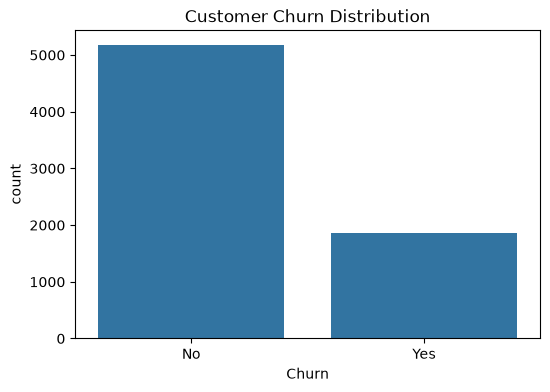

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")

plt.show()

In [11]:
numerical_cols = df.select_dtypes(
    include=["int64","float64"]
).columns

print(numerical_cols)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')


In [12]:
categorical_cols = df.select_dtypes(
    include=["object"]
).columns

print(categorical_cols)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')


/var/folders/0d/s7m_16ls28ngx5r_250804340000gn/T/ipykernel_4916/3205729808.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


# ⚙ Feature Engineering

Additional features are created to capture customer behavior patterns:

- Monthly spending categories
- Customer tenure groups
- Service usage behavior

In [13]:
print(df["TotalCharges"].dtype)

str


In [14]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

In [15]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [16]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [17]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [18]:
df["MonthlyCategory"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0,35,70,120],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

In [19]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "New",
        "Short",
        "Medium",
        "Long"
    ]
)

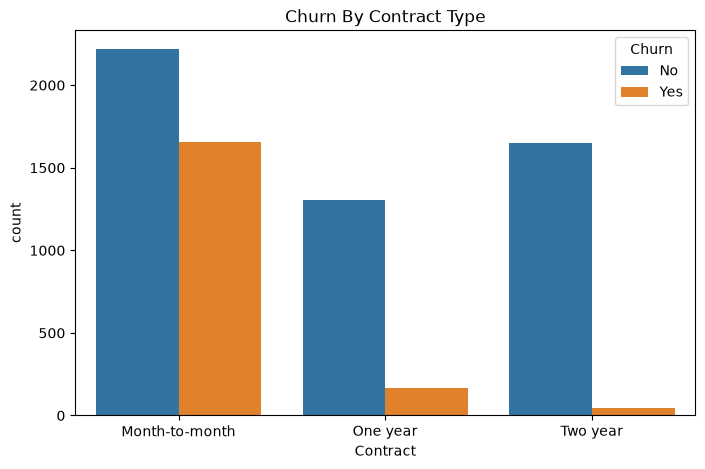

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn By Contract Type")

plt.show()

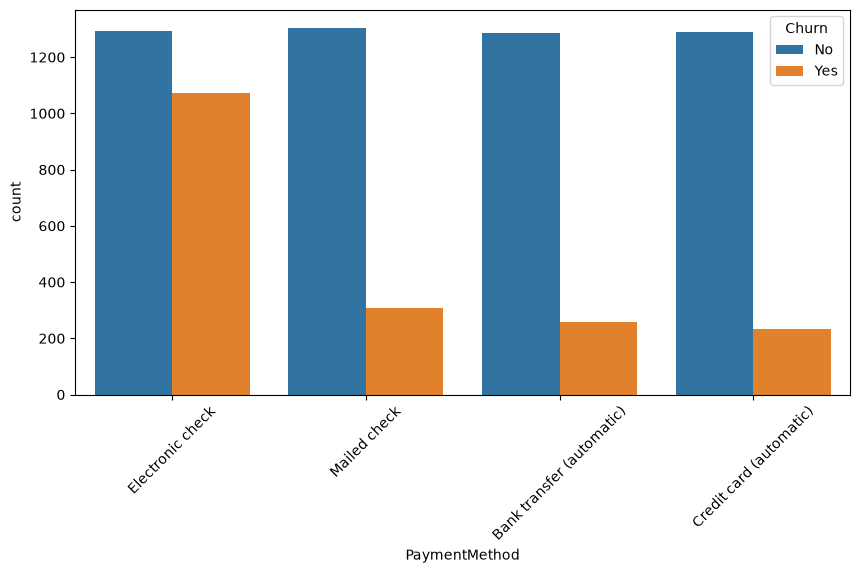

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=45)

plt.show()

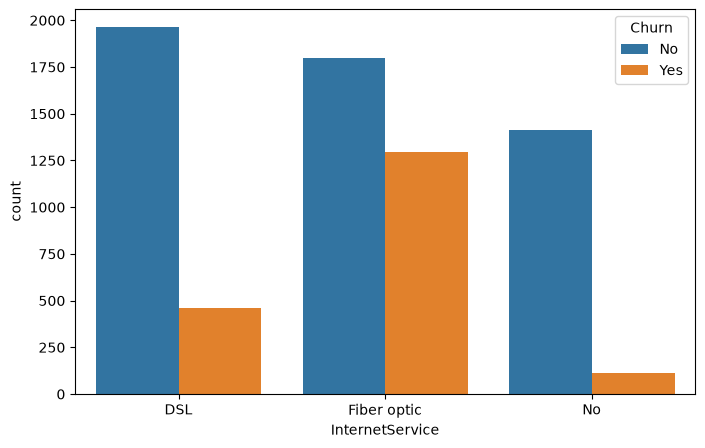

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.show()

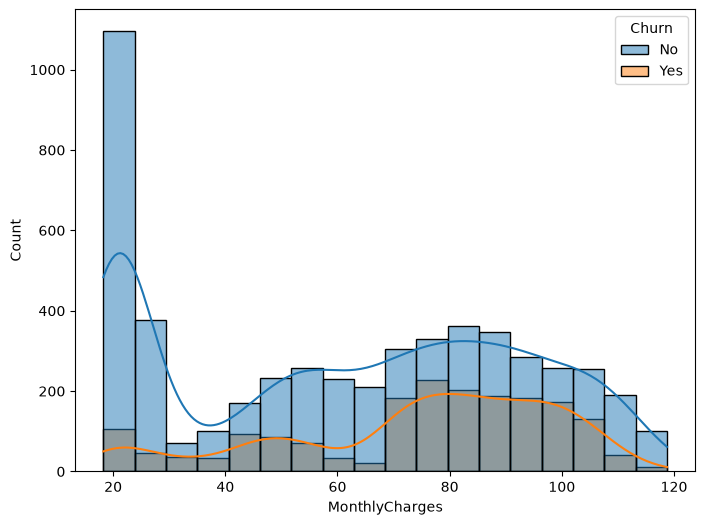

In [23]:
plt.figure(figsize=(8,6))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    kde=True
)

plt.show()

In [24]:
print(df["TotalCharges"].dtype)
print(df["TotalCharges"].isnull().sum())

float64
0


In [25]:
X = df.drop(
    columns=[
        "customerID",
        "Churn"
    ]
)

y = df["Churn"]

#  Preprocessing Pipeline

Numerical features are standardized while categorical features are one-hot encoded using a unified preprocessing pipeline.

In [26]:
num_features = X.select_dtypes(
    include=["int64","float64"]
).columns

cat_features = X.select_dtypes(
    include=["object","category"]
).columns

print(num_features)
print(cat_features)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCategory', 'TenureGroup'],
      dtype='str')


/var/folders/0d/s7m_16ls28ngx5r_250804340000gn/T/ipykernel_4916/3634035133.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(


In [27]:
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num",num_pipeline,num_features),
    ("cat",cat_pipeline,cat_features)
])

#  Splitting Dataset

The dataset is divided into training and testing subsets to evaluate model generalization performance.

In [28]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#  Random Forest Classifier

Random Forest serves as the baseline ensemble model for comparison with boosting algorithms.

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestClassifier(random_state=42))
])

In [30]:
rf_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['gender','SeniorCitizen','Partner',...,'TotalCharges','MonthlyCategory', 'TenureGroup']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

In [31]:
y_pred = rf_pipeline.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

rf_acc = accuracy_score(y_test,y_pred)

print("Accuracy:",rf_acc)

print("Classifcation Report:\n",classification_report(y_test,y_pred))

Accuracy: 0.7785663591199432
Classifcation Report:
               precision    recall  f1-score   support

          No       0.82      0.89      0.86      1035
         Yes       0.61      0.46      0.52       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.76      0.78      0.77      1409



In [33]:
from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(rf_cv)
print("CV Mean Accuracy:",rf_cv.mean())
print("CV Std:",rf_cv.std())

[0.79591837 0.79946761 0.7755102  0.77196096 0.77797513]
CV Mean Accuracy: 0.7841664552144126
CV Std: 0.011264725289039833


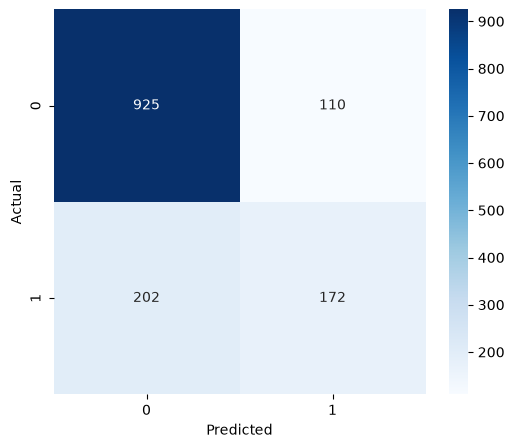

In [34]:
rf_cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

#  XGBoost Classifier

XGBoost is a powerful gradient boosting algorithm known for excellent performance on tabular datasets.

In [35]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("model",XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

In [36]:
xgb_pipeline.fit(X_train,y_train.map({
    "No":0,
    "Yes":1
}))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['gender','SeniorCitizen','Partner',...,'TotalCharges','MonthlyCategory', 'TenureGroup']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

In [37]:
y_pred_xgb = xgb_pipeline.predict(X_test)

print(classification_report(
    y_test.map({
        "No":0,
        "Yes":1
    }),
    y_pred_xgb
))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [38]:
xgb_acc = accuracy_score(y_test.map({
    "No":0,
    "Yes":1
}),y_pred_xgb)

print("Accuracy:",xgb_acc)

Accuracy: 0.7984386089425124


In [39]:
xgb_cv = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train.map({
        "No":0,
        "Yes":1
    }),
    cv=5,
    scoring="accuracy"
)

print(xgb_cv)
print("CV Mean Accuracy:",xgb_cv.mean())
print("CV Std:",xgb_cv.std())

[0.81277728 0.80035492 0.79503106 0.78083407 0.77975133]
CV Mean Accuracy: 0.7937497340429724
CV Std: 0.01241037935374727


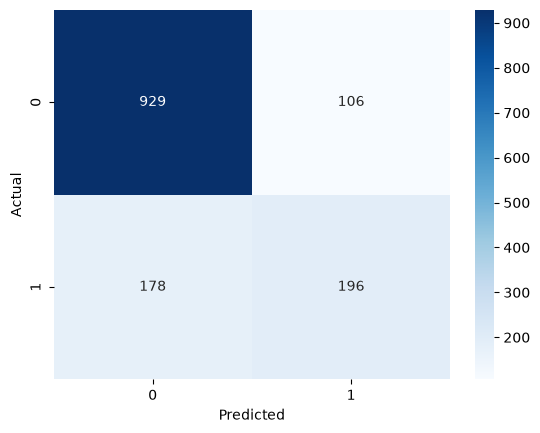

In [40]:
xgb_cm = confusion_matrix(y_test.map({
    "No":0,
    "Yes":1
}),y_pred_xgb)

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

#  Gradient Boosting Classifier

Gradient Boosting builds trees sequentially, correcting previous errors and improving prediction quality.

In [41]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("model",GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.055,
        max_depth=3,
        random_state=42
    ))
])

In [42]:
gb_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['gender','SeniorCitizen','Partner',...,'TotalCharges','MonthlyCategory', 'TenureGroup']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

In [43]:
y_pred_gb = gb_pipeline.predict(X_test)

gb_acc = accuracy_score(y_test,y_pred_gb)

print("Accuracy:",gb_acc)

Accuracy: 0.8019872249822569


In [44]:
gb_cv = cross_val_score(
    gb_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(gb_cv)
print("Mean CV Accuracy:",gb_cv.mean())
print("CV Std:",gb_cv.std())

[0.81277728 0.79325643 0.80834073 0.78527063 0.77797513]
Mean CV Accuracy: 0.7955240417272786
CV Std: 0.013267859854618142


In [45]:
print(classification_report(y_test,y_pred_gb))

              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



#  HistGradientBoosting Classifier

Histogram-based Gradient Boosting offers faster training while maintaining strong predictive performance.

In [46]:
from sklearn.ensemble import HistGradientBoostingClassifier
hist_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',HistGradientBoostingClassifier(
        learning_rate=0.0111010101015,
        max_iter=300,
        random_state=42
    ))
])

In [47]:
hist_pipeline.fit(X_train,y_train)
y_pred_hist = hist_pipeline.predict(X_test)

hist_acc = accuracy_score(y_test,y_pred_hist)
print("Accuracy:",hist_acc)

Accuracy: 0.7970191625266146


In [48]:
hist_cv = cross_val_score(
    hist_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(hist_cv)
print("Mean CV Accuracy:",hist_cv.mean())
print("CV Std:",hist_cv.std())

[0.8216504  0.8065661  0.80745342 0.78438332 0.78685613]
Mean CV Accuracy: 0.8013818733146204
CV Std: 0.013960667442546761


In [49]:
print(classification_report(y_test,y_pred_hist))

              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [50]:
import joblib
joblib.dump(gb_pipeline,"gb_model.pkl")

['gb_model.pkl']

In [51]:
X_train.columns.tolist()

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'MonthlyCategory',
 'TenureGroup']

#  Model Comparison

| Model | Accuracy |
|-------|----------|
| Random Forest | 78.28% |
| XGBoost | 80.00% |
| Gradient Boosting | 80.20% |
| HistGradientBoosting | 80.00% |

The  Gradient Boosting model achieved the best balance between overall accuracy and churn detection performance.

#  Business Insights

Key observations:

- Customers with month-to-month contracts are more likely to churn.
- High monthly charges increase churn probability.
- Electronic check payment methods show higher churn rates.
- Long-tenure customers are less likely to churn.

#  Conclusion

This project demonstrates how machine learning can help businesses proactively identify customers at risk of leaving.

The final Gradient Boosting model achieved:

- Accuracy: 80.20%
- Churn Recall: 53%
- Churn F1 Score: 59%

Future improvements may include:
- SHAP explainability
- Hyperparameter optimization using Optuna
- Streamlit deployment
- Ensemble stacking